## Improving nutrient uptake in rice/wheat rotations to reduce N2O emissions
This example script uses the data to identify possible districts that have high rice/wheat rotation $N_2O$ emissions for reduction programs.
- **Problem statement:** Both rice and wheat are high emitters in terms of per-hectare and total GHG emissions.
- **Objective:** Identify districts with low yields and high n-balance in both rice and wheat as possible districts to implement projects. These locations represent possible opportunities for yield improvement that would also reduce emissions from excess N2O, thereby generating a win-win opportunity to improve farmer income while reducing GHG emissions. 
- **Logistic:** Identify spatial clusters of districts to minimize logistic complexity.
- **Project Design:** Profile districts to aid in the design of projects to improve yield while reducing GHG emissions



#### **Step 1:** imports and setup 

In [1]:
%reload_ext autoreload
%autoreload 2

get_ipython().run_line_magic('matplotlib', 'inline')
import sys
sys.path.extend(["..\\"])
from Shared import NIBSData2
from Shared.NIBSData2 import *
import duckdb
import geopandas as gpd
import warnings
import skmisc
# Suppress all warnings
warnings.filterwarnings("ignore")

colors = ['#a6cee3','#1f78b4','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f','#ff7f00',  '#cab2d6','#6a3d9a','#ffff99','#b15928']
#nibs = NIBSData2.NIBSData()
chart_dir = "./Graphs"

### **Step 2:** create in-memory duckdb database of needed parquet table files. 
The analysis needs the following tables:
- nitrogen_universe
- data_boundaries
- vwA_apy_adj_crop_area_yield
- n2o_total_direct_n_balance_eagle_2020_summary
- state_codes

The below code demostrates how to use the helper class `NIBSData2` to load data and get the data.

In [2]:
# Create an in-memory DuckDB connection
con = duckdb.connect(database=":memory:")
con.execute("install spatial")
con.execute("load spatial")
con.execute("SET default_collation = 'nocase';")

# Tables/views listed in the notebook markdown
required_parquets = [
    "nitrogen_universe",
    "data_boundaries",
    "vwA_apy_adj_crop_area_yield",
    "n2o_total_direct_n_balance_eagle_2020_summary",
    "state_codes",
    "national_boundaries",
    "state_boundaries",
    "fertilizer_input",
    "shc_crop_npk_requirements",
    "shc_district_micro_nutrient_summary",
    "shc_parameter_units",
    "state_codes",
    "apy",
]

loaded = []
missing = []

# load non-spatial tables
for name in required_parquets:
    url = nib_urls.get(name)
    if url:
        con.execute(f'''
            CREATE OR REPLACE TABLE "{name}" AS
            SELECT * FROM read_parquet('{url}')
        ''')
        loaded.append(name)
    else:
        missing.append(name)

# load spatial table
# url = nib_urls.get("data_boundaries")
# if url:
#     con.execute(f'''
#         CREATE OR REPLACE TABLE "data_boundaries" AS
#         SELECT * EXCLUDE geog, (CAST(geog AS string)) AS geog FROM read_parquet('{url}')
#     ''')
#     loaded.append("data_boundaries")
# else:
#     missing.append("data_boundaries")
 
print("Loaded:", loaded)   
if missing:
    print("Missing in nib_urls:", missing)

# Optional: verify what is available in the in-memory database
con.sql("SHOW TABLES").df()

Loaded: ['nitrogen_universe', 'data_boundaries', 'vwA_apy_adj_crop_area_yield', 'n2o_total_direct_n_balance_eagle_2020_summary', 'state_codes', 'national_boundaries', 'state_boundaries', 'fertilizer_input', 'shc_crop_npk_requirements', 'state_codes', 'apy']
Missing in nib_urls: ['shc_district_micro_nutrient_summary', 'shc_parameter_units']


,name
0,apy
1,data_boundaries
2,fertilizer_input
3,n2o_total_direct_n_balance_eagle_2020_summary
4,national_boundaries
5,nitrogen_universe
6,shc_crop_npk_requirements
7,state_boundaries
8,state_codes
9,vwA_apy_adj_crop_area_yield


### **Step 3:** Build a dataset of districts that produce both rice and wheat.
This is a complicated SQL query that uses the database created above to find districts that produce both rice and wheat and return their $N_2O$ emissions and spatial bounds. 

**NOTE:** the query uses the data_boundaries dataset and not the district_boundaries dataset. This is because the state of Punjab has only a state-wide result, because the input survey results for that state are incomplete.


In [3]:
sql = """
with a as
	(
	select 
 		r.link_id as rice_id, w.link_id as wheat_id, r.crop, r.apy_crop as rice_crop, w.apy_crop as wheat_crop
		, ROW_NUMBER() over(order by w.link_id) as rotation_id
		,ROW_NUMBER() over(partition by r.geog_checksum, r.IRRIGATION_STATUS, r.SIZE_GROUPHA order by len(r.crop)) as dups
		,concat(district_name,'(',state_code,')') as label
		,state_code 
	from nitrogen_universe as r 
		join nitrogen_universe as w on r.geog_checksum = w.geog_checksum 
			and r.SIZE_GROUPHA = w.SIZE_GROUPHA
			and r.IRRIGATION_STATUS = w.IRRIGATION_STATUS
			and lower(r.apy_crop) = 'rice'
			and lower(w.apy_crop) = 'wheat'
		join data_boundaries as db on db.geog_checksum = r.geog_checksum
			and db.geog_checksum = w.geog_checksum
		join state_codes as sc on lower(sc.state_name) = lower(db.state_name) 
	)
,b as
	(
	select u.link_id
		,a.rotation_id
		, u.geog_checksum
		, label
		,state_code 
		, u.apy_crop
		, farm_size 
		, irrigated 
		, u.adj_crop_area
		, u.adj_fert_area
		, u.mean_yield as mean_yield_t_ha
		, u.sd_yield as sd_yield_t_ha
		,mean_total_n_balance_n_kg_ha
		,sd_total_n_balance_n_kg_ha 
	from vwA_apy_adj_crop_area_yield as u 
		join n2o_total_direct_n_balance_eagle_2020_summary as n on u.link_id = n.link_id
		join a on a.rice_id = u.link_id
	where dups = 1
	union
	select u.link_id
		,a.rotation_id
		, u.geog_checksum
		, label
		,state_code 
		, u.apy_crop
		, farm_size 
		, irrigated 
		, u.adj_crop_area
		, u.adj_fert_area
		, u.mean_yield as mean_yield_t_ha
		, u.sd_yield as sd_yield_t_ha
		,mean_total_n_balance_n_kg_ha
		,sd_total_n_balance_n_kg_ha 
	from vwA_apy_adj_crop_area_yield as u 
		join n2o_total_direct_n_balance_eagle_2020_summary as n on u.link_id = n.link_id
		join a on a.wheat_id = u.link_id
	where dups = 1
	)
,c as
	(
	select *
		,count(*) over(partition by rotation_id) as rcnt
	from b 
	)
select c.*
	,cast(geog as string) as geog
	,label_x
	,label_y 
from c
	join data_boundaries as d on d.geog_checksum = c.geog_checksum
where rcnt = 2;
""" 

# table = ['nitrogen_universe', 'data_boundaries', 'vwA_apy_adj_crop_area_yield', 'n2o_total_direct_n_balance_eagle_2020_summary', 'state_codes']

# for t in table:
# 	print(f"Sample from {t}:")
# 	print(con.execute(f"SELECT * FROM {t} LIMIT 5").fetch_df())

# sql = "select geog from data_boundaries limit 5"

df = con.execute(sql).fetch_df()
rice_wheat_gdf = gpd.GeoDataFrame(df,geometry= gpd.GeoSeries.from_wkt(df['geog']),crs=4326)
rice_wheat_gdf.head(3)

,link_id,rotation_id,geog_checksum,label,state_code,apy_crop,farm_size,irrigated,adj_crop_area,adj_fert_area,mean_yield_t_ha,sd_yield_t_ha,mean_total_n_balance_n_kg_ha,sd_total_n_balance_n_kg_ha,rcnt,geog,label_x,label_y,geometry
0,-2556190698396902204,80,1981673543,Jyotiba Phule Nagar(UP),UP,Rice,MEDIUM (4.0 - 9.99),I,1331.326430,16.386986,2.322949,0.245603,191.717121,22.200125,2,"POLYGON ((78.1059246 29.0834462, 78.0925883 29...",78.3294,28.8135,"POLYGON ((78.10592 29.08345, 78.09259 29.07833..."
1,-9004847403858430320,80,1981673543,Jyotiba Phule Nagar(UP),UP,Wheat,MEDIUM (4.0 - 9.99),I,7344.615545,576.059700,3.213551,0.700595,137.888623,18.592411,2,"POLYGON ((78.1059246 29.0834462, 78.0925883 29...",78.3294,28.8135,"POLYGON ((78.10592 29.08345, 78.09259 29.07833..."
2,-8992185940145162137,86,-685168729,Lalitpur(UP),UP,Wheat,MARGINAL (BELOW 1.0),I,21732.484636,2547.550199,2.666164,0.681179,135.290573,17.566992,2,"POLYGON ((78.5695982 25.2209502, 78.5651838 25...",78.5619,24.6533,"POLYGON ((78.5696 25.22095, 78.56518 25.21864,..."


### **Step 4:** District yield vs n-balance graph
This code graphs the district yield on the y-axis and the n-balance on the x-axis for both rice and wheat. The bottom quadrant of the graph represents districts with high N balance (overapplication of N) and low yields. These districts, as highlighted in the red box on the graph, can be targeted for projects to increase yields for supporting farmer livelihoods, which would also reduce excess $N_2O$ emissions. 

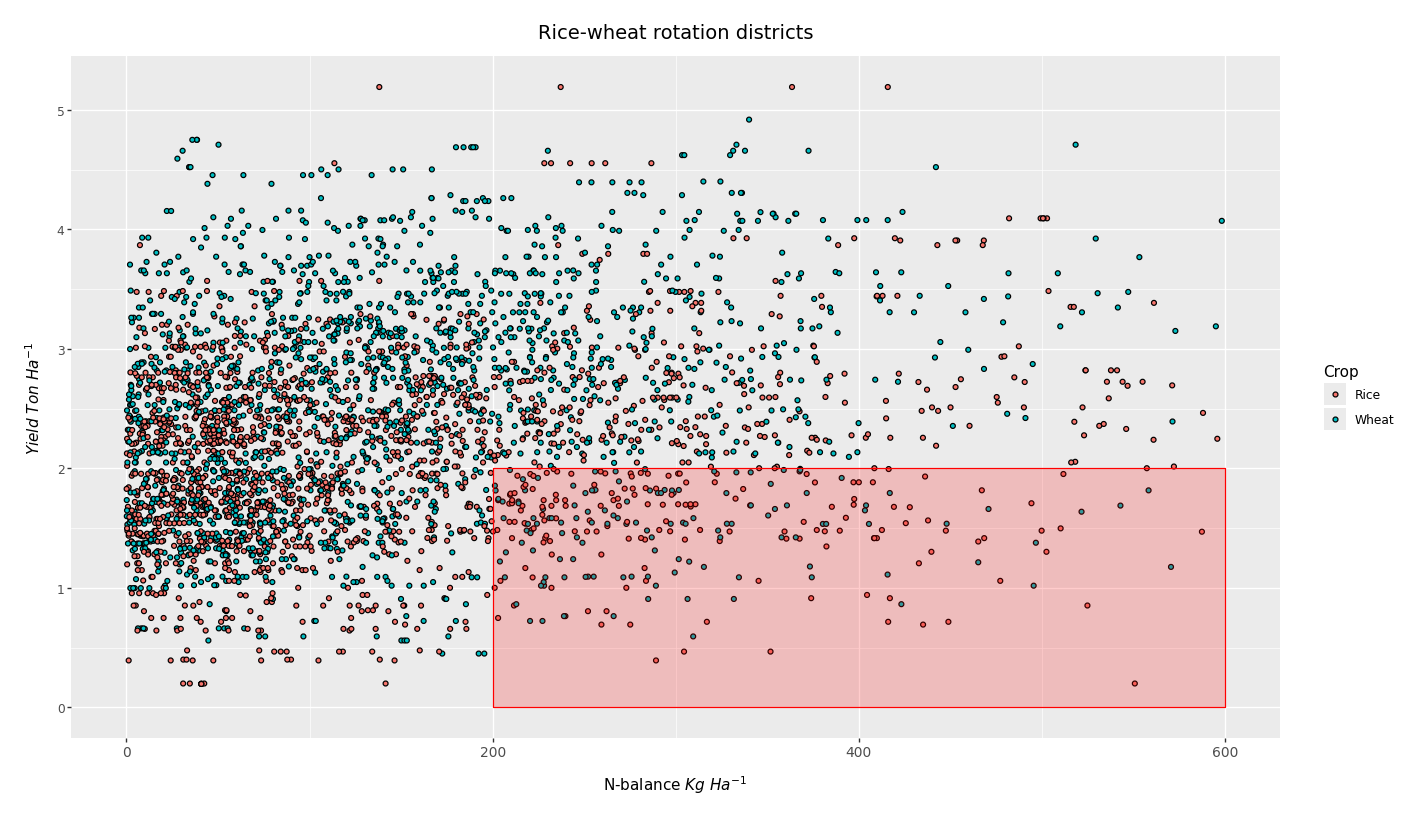

In [4]:
p = (ggplot(rice_wheat_gdf)
            + geom_point(aes(x='mean_total_n_balance_n_kg_ha', y='mean_yield_t_ha',fill='apy_crop'))
            + scale_fill_discrete(name='Crop')
             + labs(title='Rice-wheat rotation districts', x="N-balance $Kg\ Ha^{-1}$", y="$Yield\ Ton\ Ha^{-1}$")
                 + annotate(
                "rect",
                xmin=200, xmax=600,
                ymin=0, ymax=2,
                fill="red",
                alpha=0.2,      # keep it translucent so data underneath stays visible
                color="red",    # red border
            )
            + scale_x_continuous(limits=(0, 600))
            #+ guides(fill=None) 
             + theme(figure_size=(14,8), axis_text_x=element_text(angle=0, va="top", ha="center", size=10),
             plot_title=element_text(ha='center', size=14))
            )

p.save(filename=f"rice_wheat_n_balance_target_full.png", path=chart_dir, height=12, width=22, units='cm', dpi=92)
p.show()



### **Step 5:** Identify target districts.
Using what we have learned from the graph above, we will now find the district where both rice and wheat fall within the target zone identified above.


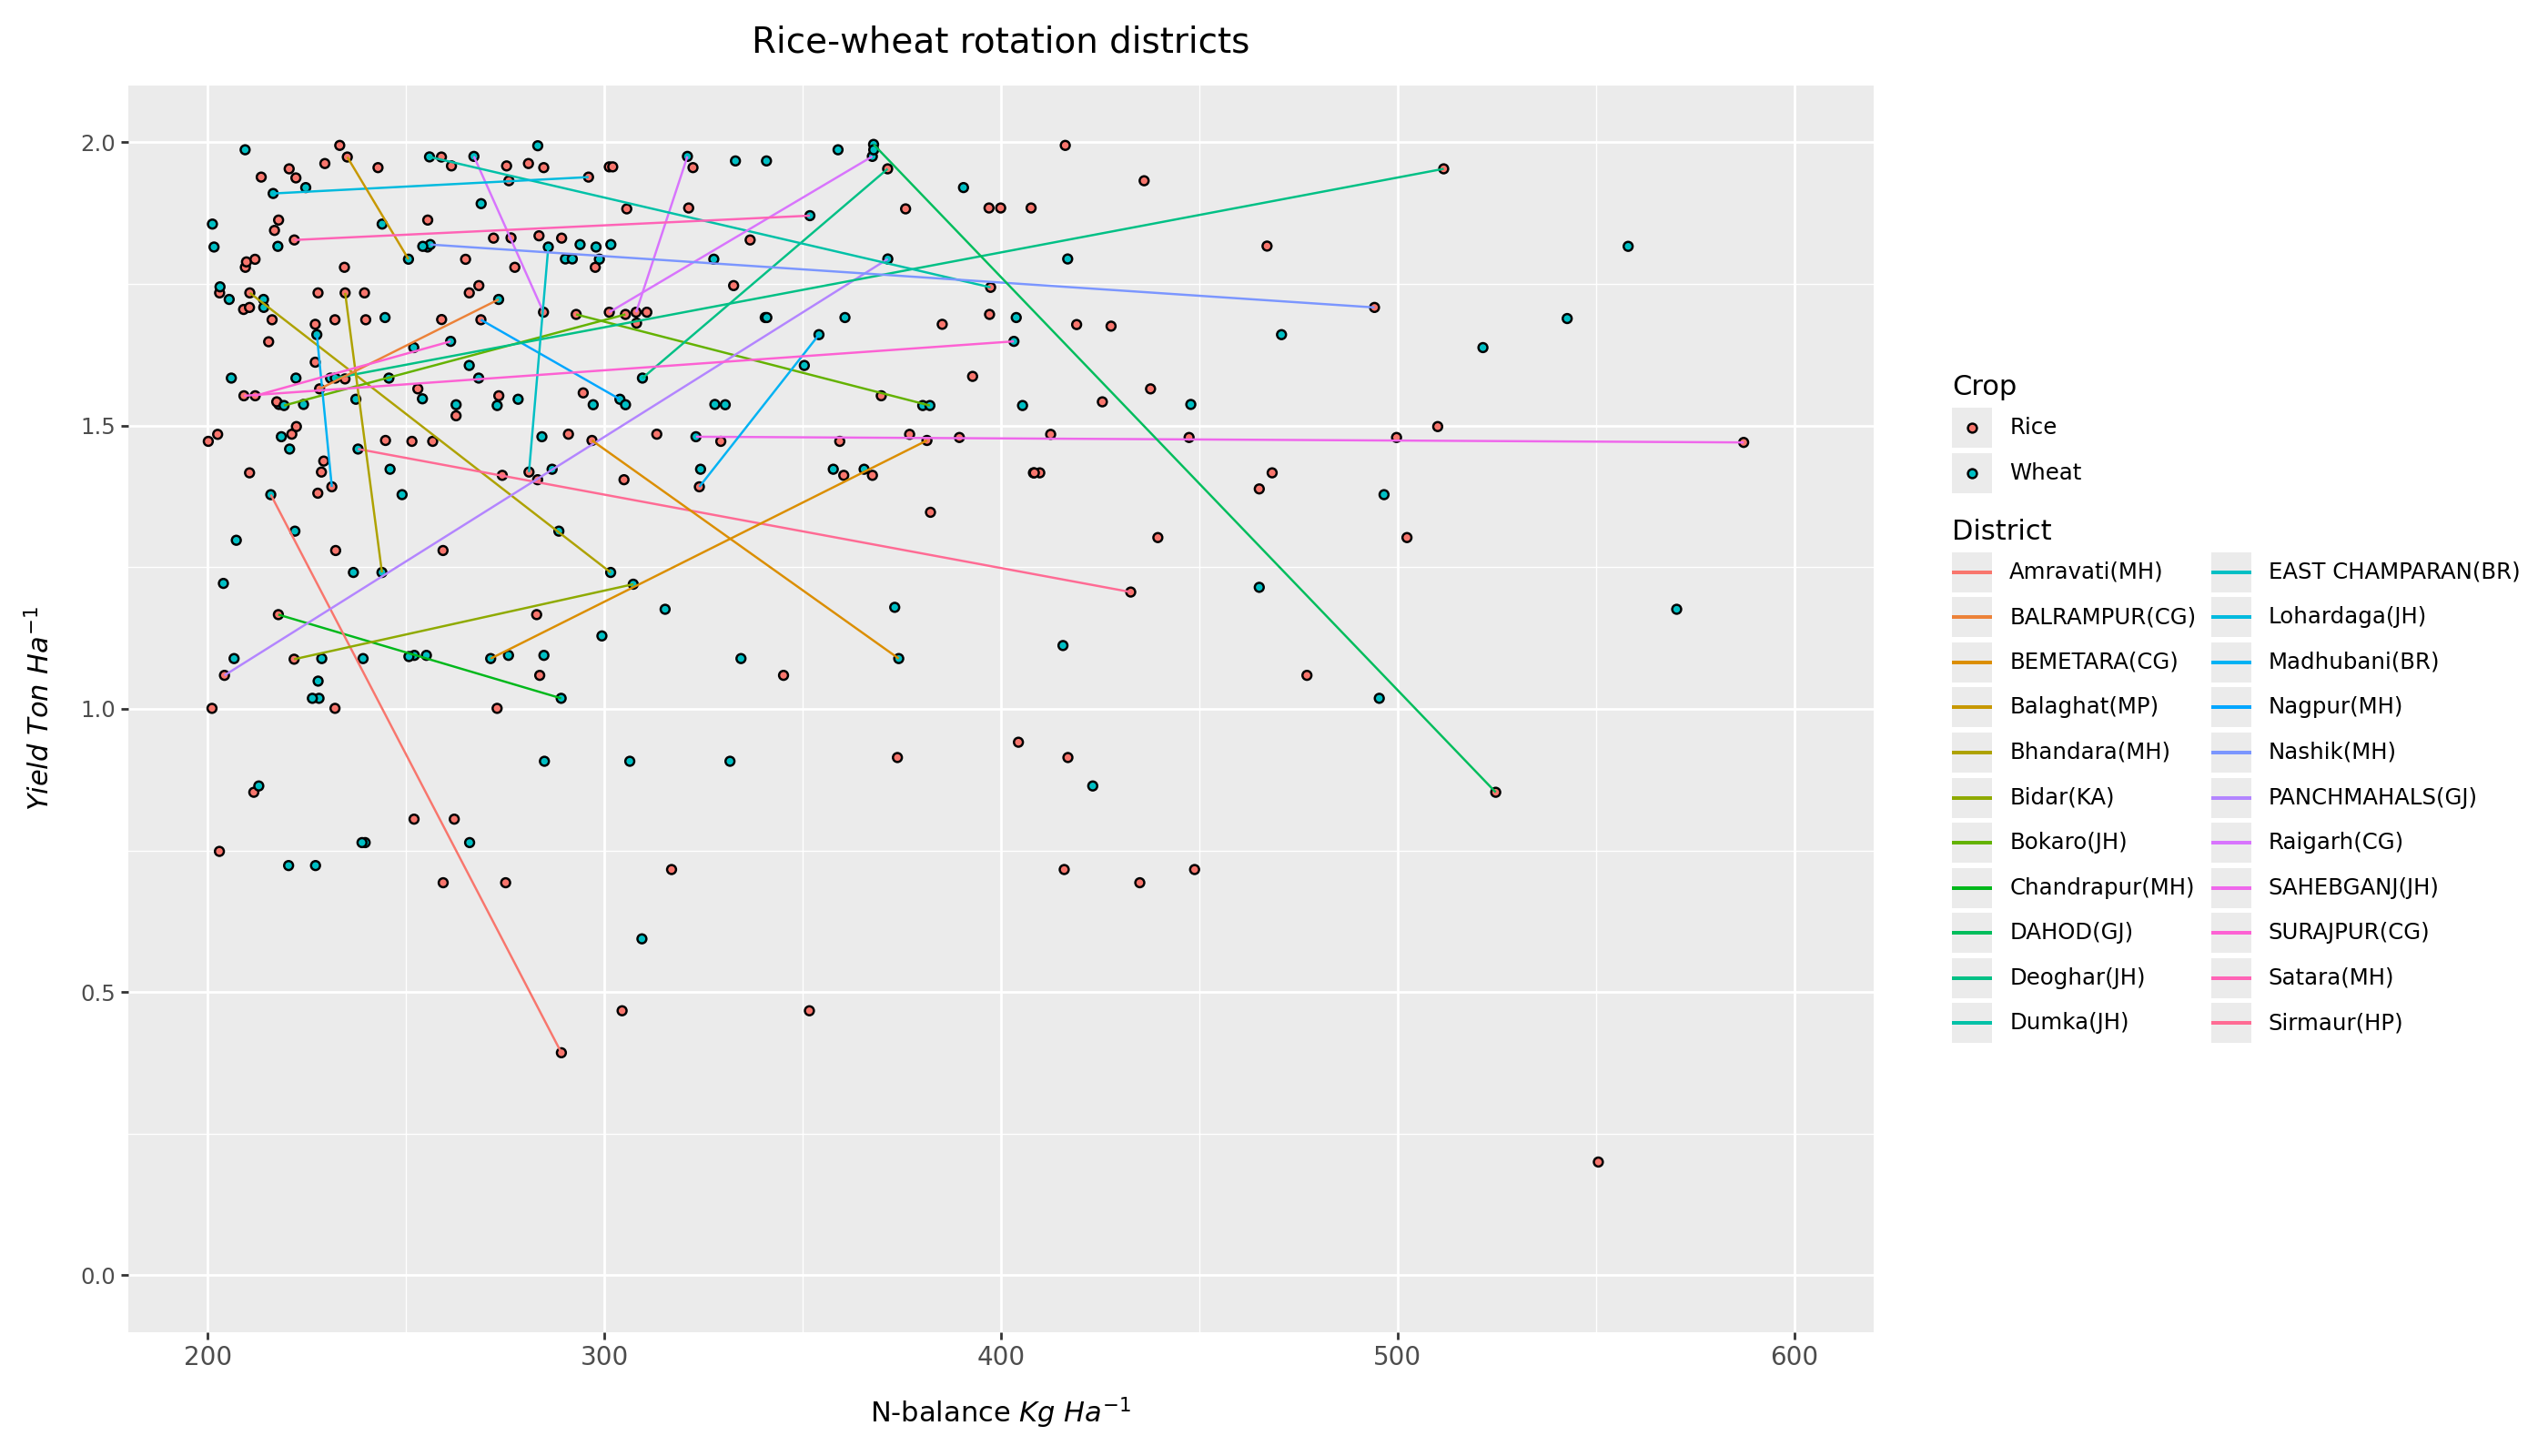

In [5]:
#filter the rice-wheat rotation districts that are in the target zone (N-balance > 200 and yield < 2)
filter_gdf = rice_wheat_gdf[(rice_wheat_gdf['mean_total_n_balance_n_kg_ha'] > 200) & (rice_wheat_gdf['mean_yield_t_ha'] < 2)]

#create the dataset the links the rice and wheat for a districts together by rotation_id
grouped_df = filter_gdf.groupby('rotation_id').size().reset_index(name='counts')
line_rid = grouped_df[grouped_df['counts'] > 1]['rotation_id']
line_df = filter_gdf[filter_gdf['rotation_id'].isin(line_rid)] 
line_df['mean_total_n_balance_n_kg_kg_yield'] =line_df['mean_total_n_balance_n_kg_ha']/line_df['mean_yield_t_ha'] 
line_cnt_gdf = line_df.groupby('label').size().reset_index(name='counts')
line_cnt_gdf

#graph the rice-wheat rotation districts that are in the target zone (N-balance > 200 and yield < 2) with lines connecting the rice and wheat for a district
p = (ggplot(filter_gdf)
            # + geom_violin(filter_df,aes(x='dataset', y='kg_inorganic_n_ha'),draw_quantiles=[0.25, 0.5, 0.75])
            + geom_point(aes(x='mean_total_n_balance_n_kg_ha', y='mean_yield_t_ha',fill='apy_crop'))
        #     + geom_errorbar(aes(x='label_simple', ymin='mean_co2e_Mt - sd_co2e_Mt', ymax='mean_co2e_Mt + sd_co2e_Mt'), width=0.2)
        #   + geom_text(aes(x='label_simple', y='mean_co2e_Mt', label='mean_co2e_Mt'), 
        #          va='bottom', ha='center', size=8, format_string='{:.2f}')
    
            # + geom_jitter(filter_df, aes(x='dataset', y='kg_inorganic_n_ha'), color='blue', alpha=.01, size=.001, width=0.3)
             + labs(title='Rice-wheat rotation districts', x="N-balance $Kg\ Ha^{-1}$", y="$Yield\ Ton\ Ha^{-1}$")
            # + scale_y_log10()
            + scale_fill_discrete(name='Crop')
            + scale_y_continuous(limits=(0, 2))
            + scale_x_continuous(limits=(200, 600))
            + geom_line(line_df, aes(x='mean_total_n_balance_n_kg_ha', y='mean_yield_t_ha', group='rotation_id', color='label'))
    
            + scale_color_discrete(name='District')
            #  +scale_y_continuous(limits=(0, 375))
            #+ guides(fill=None) 
             + theme(figure_size=(14,8),axis_text_x=element_text(angle=0, va="top", ha="center", size=10),
             plot_title=element_text(ha='center', size=14))
            # + facet_wrap('~gwp_label')
            )
p.save(filename=f"rice_wheat_n_balance_target_zoom.png", path=chart_dir, units='cm', dpi=92)
p

### **Step 6:** Identify spatial clustering
Now we would like to identify any spatial clustering of districts that would be ideal for developing a project to increase yields and reduce $N_2O$ emissions.


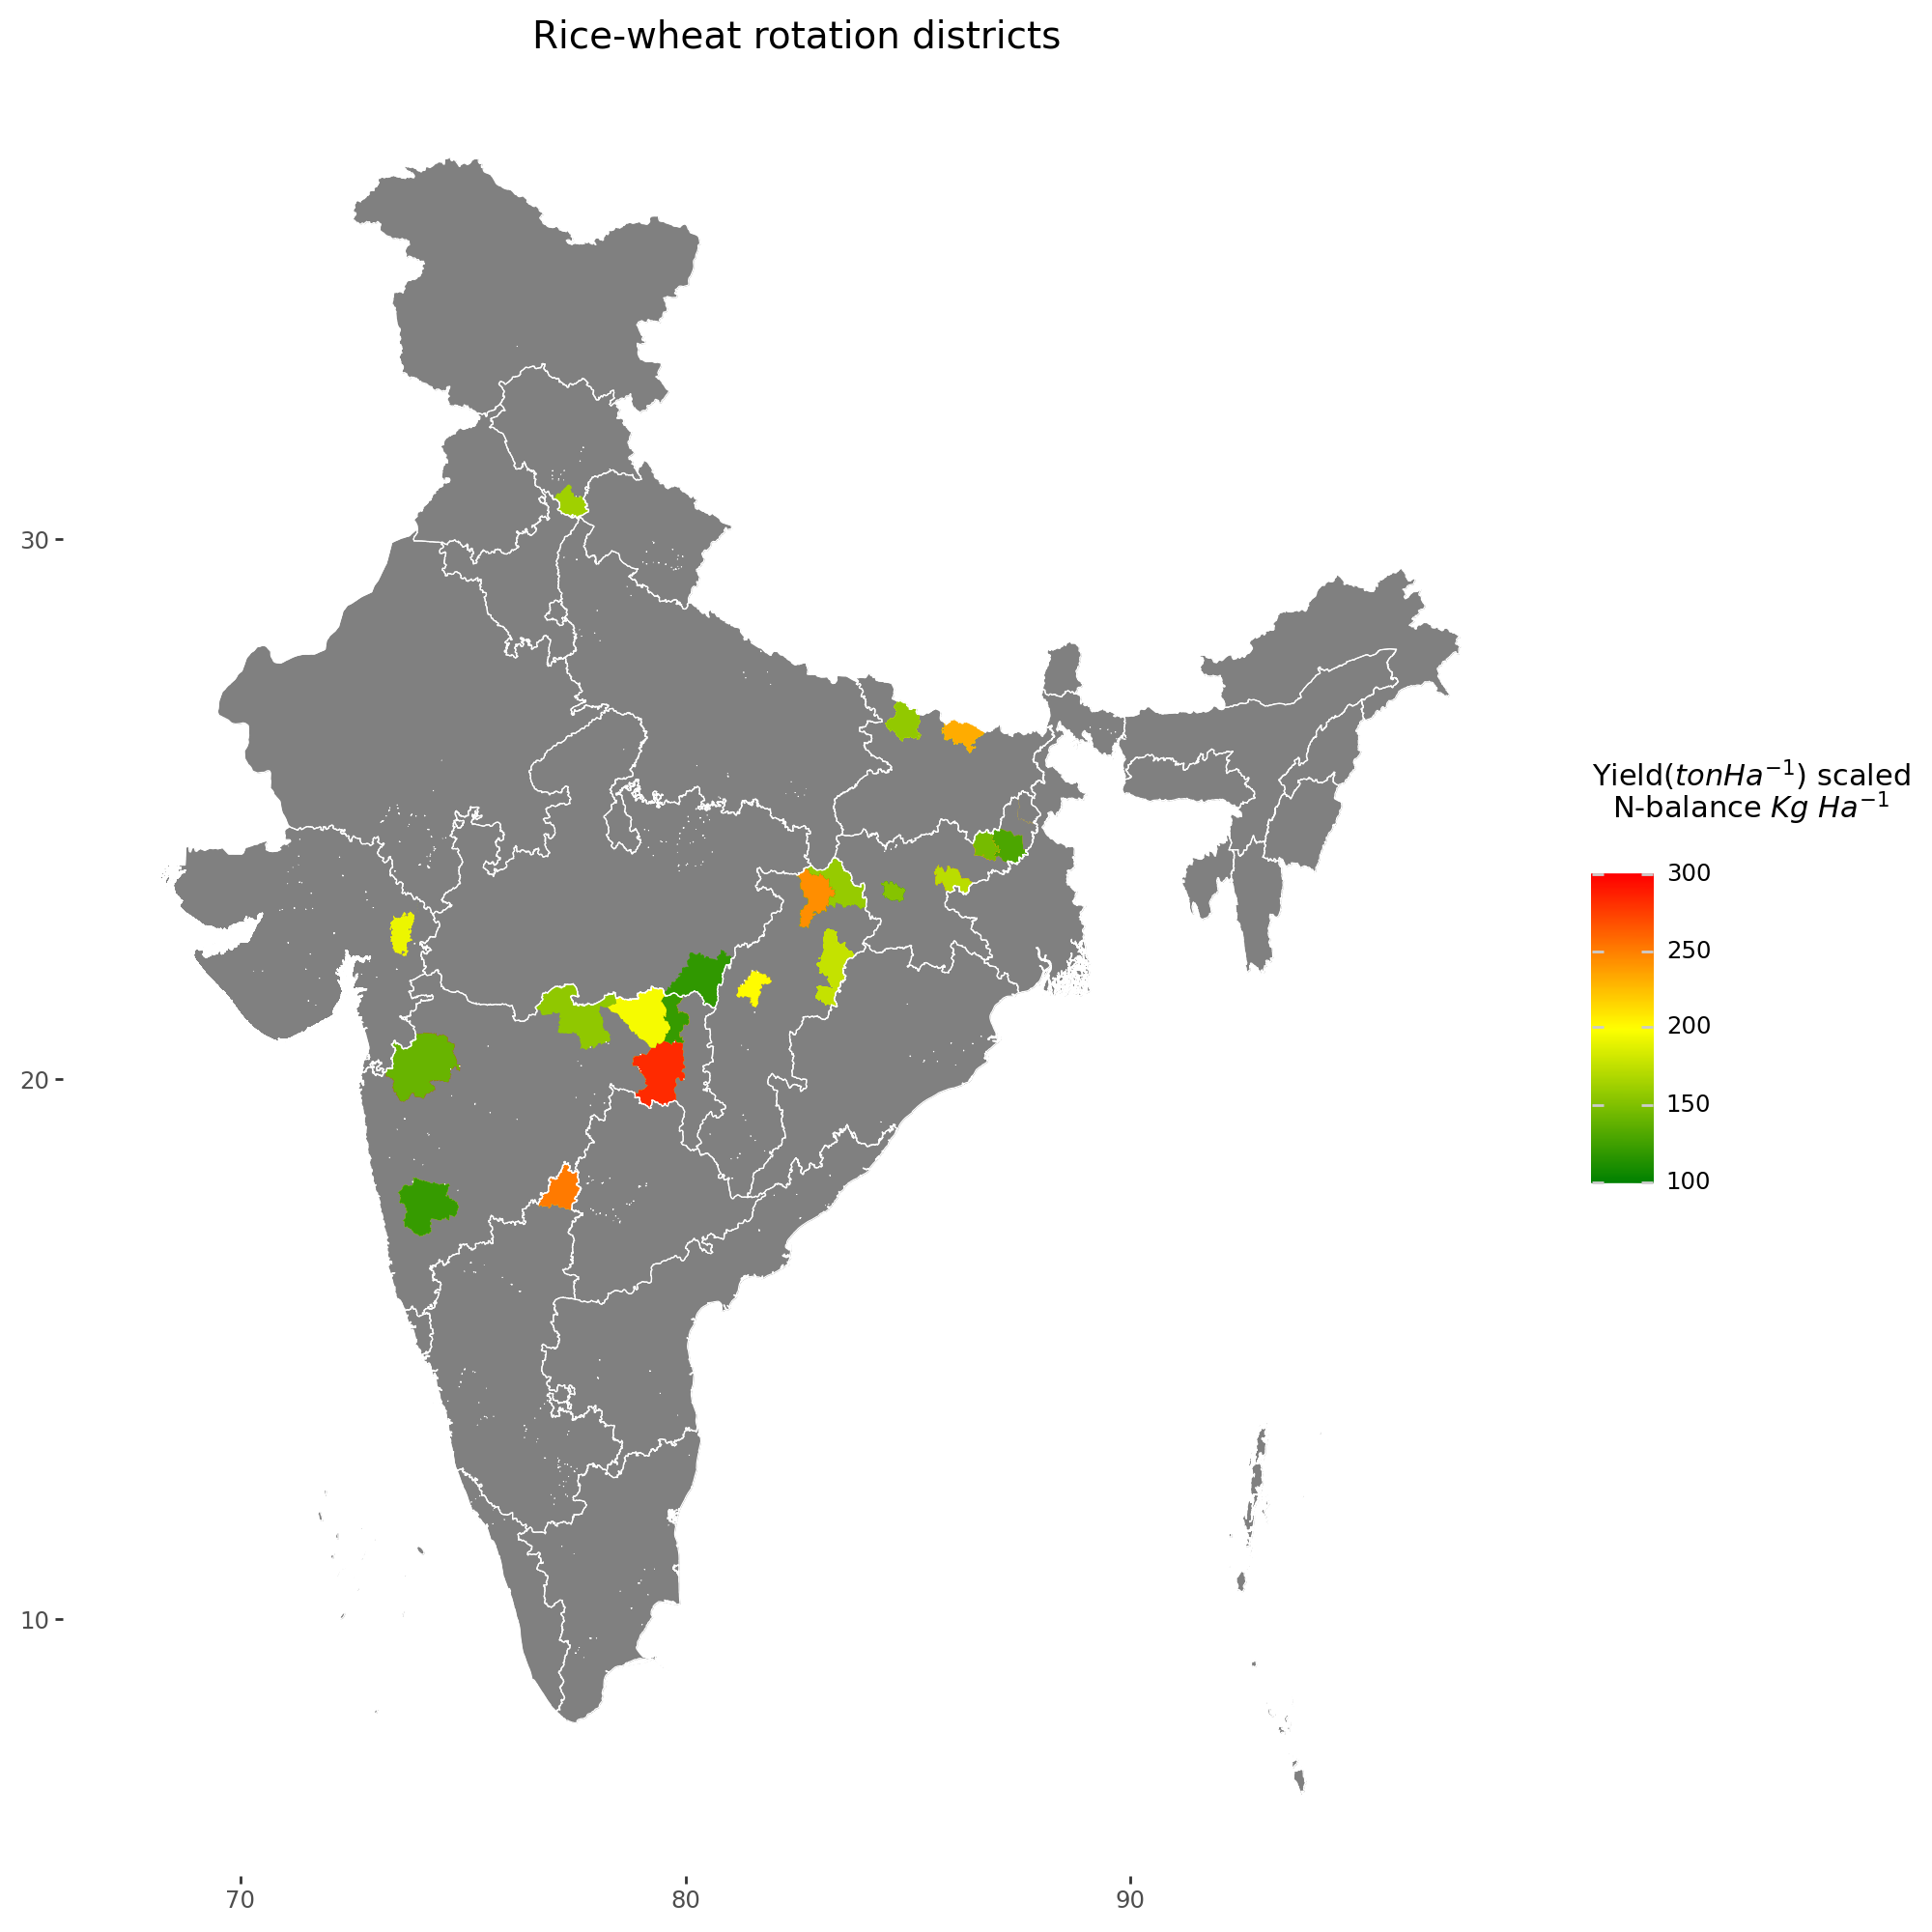

In [6]:
#load the India national and state boundaries
india_df = con.execute("SELECT * EXCLUDE geog, (CAST(geog AS string)) AS geog FROM national_boundaries").fetch_df()
india = gpd.GeoDataFrame(india_df, geometry=gpd.GeoSeries.from_wkt(india_df['geog']), crs=4326)
state_df = con.execute("SELECT * EXCLUDE geog, (CAST(geog AS string)) AS geog FROM state_boundaries order by state_code").fetch_df()
india_states = gpd.GeoDataFrame(state_df, geometry=gpd.GeoSeries.from_wkt(state_df['geog']), crs=4326)
                                
#create map graph
units = "Yield($ton Ha^{-1}$) scaled\nN-balance $Kg\ Ha^{-1}$\n"
low_color = "green"
mid_color= "yellow"
high_color = "red"
g = (ggplot()
     + geom_map(india, fill='grey', color=None, show_legend=False)
     #+ scale_fill_brewer(type='div', palette=8)
     + scale_x_continuous(limits=(67.5,97.5))
     #+ scale_y_continuous(limits=(7.5,37.5))
     + coord_cartesian()
     + geom_map(line_df, aes(fill="mean_total_n_balance_n_kg_kg_yield"), color=None, show_legend=True)
     + geom_map(india_states, color="white", fill=None, size=.25, show_legend=False)
     + labs(title='Rice-wheat rotation districts')
     + scale_fill_gradient2(low=low_color, mid=mid_color, midpoint=200, high=high_color, name=units, limits=[100,300])
     + theme(
         figure_size=(10, 10),
         rect=element_rect(fill=(0, 0, 0, 0), color=(0, 0, 0, 0)),
         strip_background=element_rect(fill='white', color='white'),
         plot_title=element_text(ha='center', size=14)
     )
)

#g.save(filename="map_rice_wheat_targets.png", path=chart_dir,  units='cm', dpi=300)
g



### **Step 7:** Profile target districts
Once the target districts for a project are identified, we can now profile each target district to better understand its production attributes. We will start by profiling their irrigation status and farm size for those with low yields and high $N_2O$ emissions.


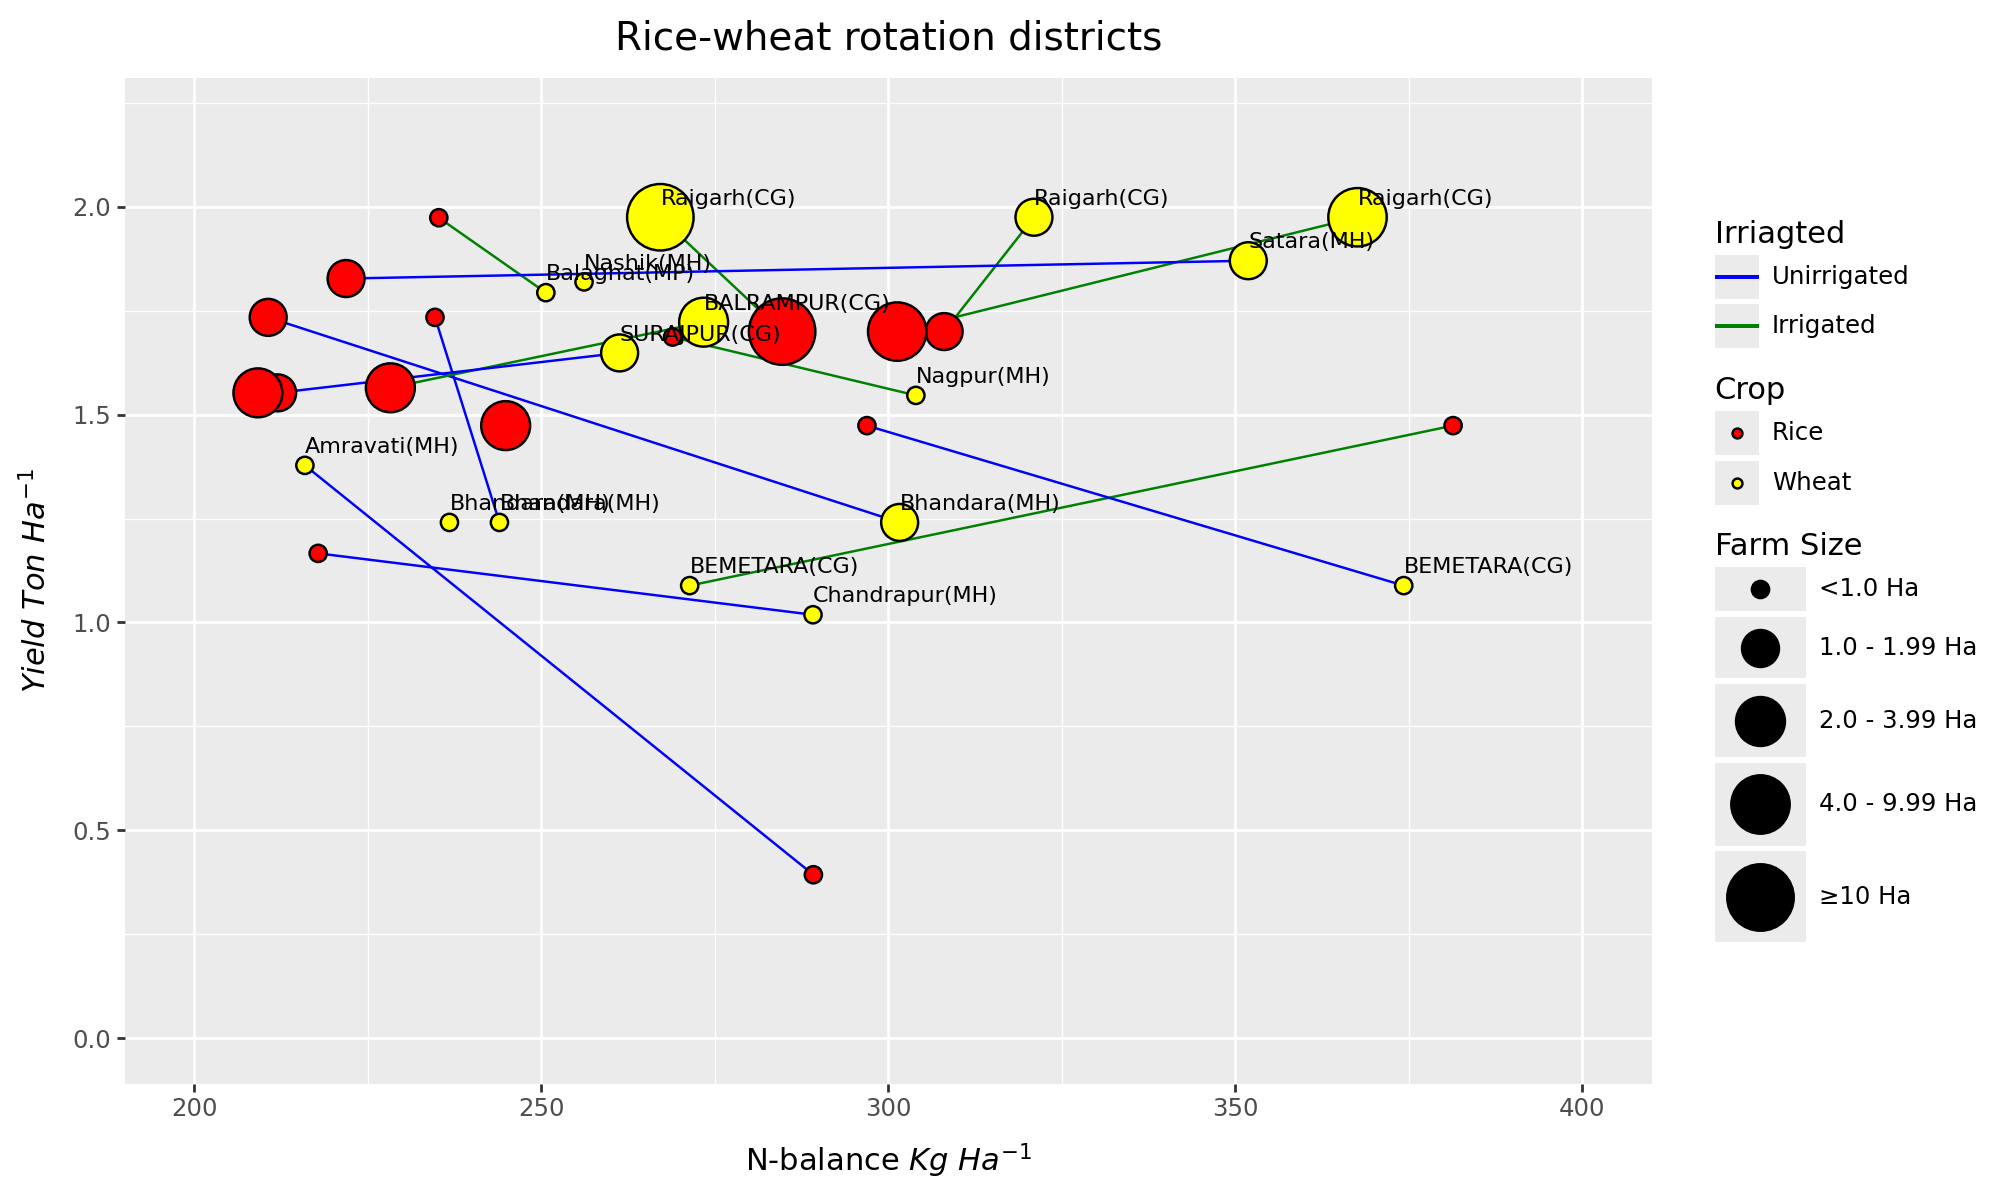

In [7]:
#create a dataset of spatially clustered rice-wheat rotation districts in the target zone (N-balance > 200 and yield < 2) with lines connecting the rice and wheat for a district   
target_df = line_df[(line_df['state_code'] == 'MH') | (line_df['state_code'] == 'MP') | (line_df['state_code'] == 'CG')]
target_df.loc[target_df['apy_crop'] == 'Rice', 'label'] = ''
target_df
target_df['farm_size'] = pd.Categorical(target_df['farm_size']
                                    , categories=[ 'MARGINAL (BELOW 1.0)', 'SMALL (1.0 - 1.99)', 'SEMI-MEDIUM (2.0 - 3.99)','MEDIUM (4.0 - 9.99)','LARGE (10 AND ABOVE)' ], ordered=True)
target_df['farm_size'] = target_df['farm_size'].cat.rename_categories({'MARGINAL (BELOW 1.0)': '<1.0 Ha',
                                                                        'SMALL (1.0 - 1.99)': '1.0 - 1.99 Ha',
                                                                        'SEMI-MEDIUM (2.0 - 3.99)': '2.0 - 3.99 Ha',
                                                                        'MEDIUM (4.0 - 9.99)': '4.0 - 9.99 Ha',
                                                                        'LARGE (10 AND ABOVE)': '≥10 Ha'    })
target_df['irrigated'] = pd.Categorical(target_df['irrigated']
                                    , categories=['UI','I'], ordered=True)
target_df['irrigated'] = target_df['irrigated'].cat.rename_categories({'UI': 'Unirrigated', 'I': 'Irrigated'})
target_df


#graph the rice-wheat rotation districts use color to represent crop (Rice or Wheat), size to represent farm size, and line to connect the rice and wheat to show the irr
g = (ggplot(target_df,aes(x='mean_total_n_balance_n_kg_ha', y='mean_yield_t_ha'))
    + geom_line(aes(group='rotation_id', color='irrigated'))
    + geom_point(aes(fill='apy_crop', size='farm_size')) 
    + geom_text(aes( label='label', adjust_text=True), va='bottom', ha='left', size=8, format_string='{:}', nudge_x=0.02, nudge_y=0.02)
    + labs(title='Rice-wheat rotation districts', x="N-balance $Kg\ Ha^{-1}$", y="$Yield\ Ton\ Ha^{-1}$")
    
     + scale_color_manual(name='Irriagted',values={'Unirrigated': 'blue', 'Irrigated': 'green'})
     + scale_fill_manual(name='Crop',values={'Rice': 'red', 'Wheat': 'yellow'})
     + scale_size_discrete(name='Farm Size', range=[3,13])
     + scale_x_continuous(limits=(200, 400))
     + scale_y_continuous(limits=(0, 2.2))
     + theme(
         figure_size=(10, 6),
        # rect=element_rect(fill=(0, 0, 0, 0), color=(0, 0, 0, 0)),
         #strip_background=element_rect(fill='white', color='white'),
         plot_title=element_text(ha='center', size=14)
     )
)
g.save(filename="rice_wheat_targets_detail.png", path=chart_dir, units='cm', dpi=300)
g

### **Step 8:** Profile district yield and crop area.
Profile the target districts to examine their yields of rice and wheat over time relative to the all-India average. Determine whether there is sufficient crop area to implement a project and achieve the required scale.


In [8]:
apy_sql = """with a as
	(
	select concat(district_name,'(',state_code,')') as district 
		,apy_crop, year
		,area, production, yield	
		,season
		,row_number() over(partition by apy.state_name,district_name,apy_crop,year order by if(season='total',0,1)) as rno
	from apy 
		join state_codes sc on sc.state_name = apy.state_name
	where geog_checksum in(357371350,-2066345052,931355363,1626958676,2076785716,2072171870)--,384966572,1310434990
		and apy_crop in('rice','wheat')
	)
,b as (
	select 'All India' as district 
		,apy_crop, year
		,area, production, yield	
		,season
		,row_number() over(partition by apy.state_name,district_name,apy_crop,year order by if(season='total',0,1)) as rno
	from apy 
		join state_codes sc on sc.state_name = apy.state_name
	--where geog_checksum not in(357371350,-2066345052,931355363,1626958676,2076785716,2072171870)--,384966572,1310434990
		and apy_crop in('rice','wheat')
        and year <> '2019-20'   
    )
select district, apy_crop, year, area, production, yield
from a
where rno = 1
union
select district, apy_crop, year, area, production, yield
from b
where rno = 1
"""
apy_df = con.execute(apy_sql).fetch_df()

apy_df['district'] = pd.Categorical(apy_df['district'], categories=['RAIGARH(CG)', 'BALAGHAT(MP)', 'AMRAVATI(MH)', 'CHANDRAPUR(MH)', 'NAGPUR(MH)', 'NASHIK(MH)', 'All India'], ordered=True)
apy_df.head()

,district,apy_crop,year,area,production,yield
0,NASHIK(MH),Rice,2014-15,71200.0,86700.0,1.217697
1,BALAGHAT(MP),Rice,2006-07,248652.0,299342.0,1.203859
2,BALAGHAT(MP),Rice,2018-19,300301.0,603446.0,2.009470
3,AMRAVATI(MH),Wheat,2007-08,53700.0,101500.0,1.890130
4,CHANDRAPUR(MH),Rice,2014-15,145800.0,113500.0,0.778464


Create graph of target district yields over time against the all India average. The graph shows the target districts are below all India average with different trends.

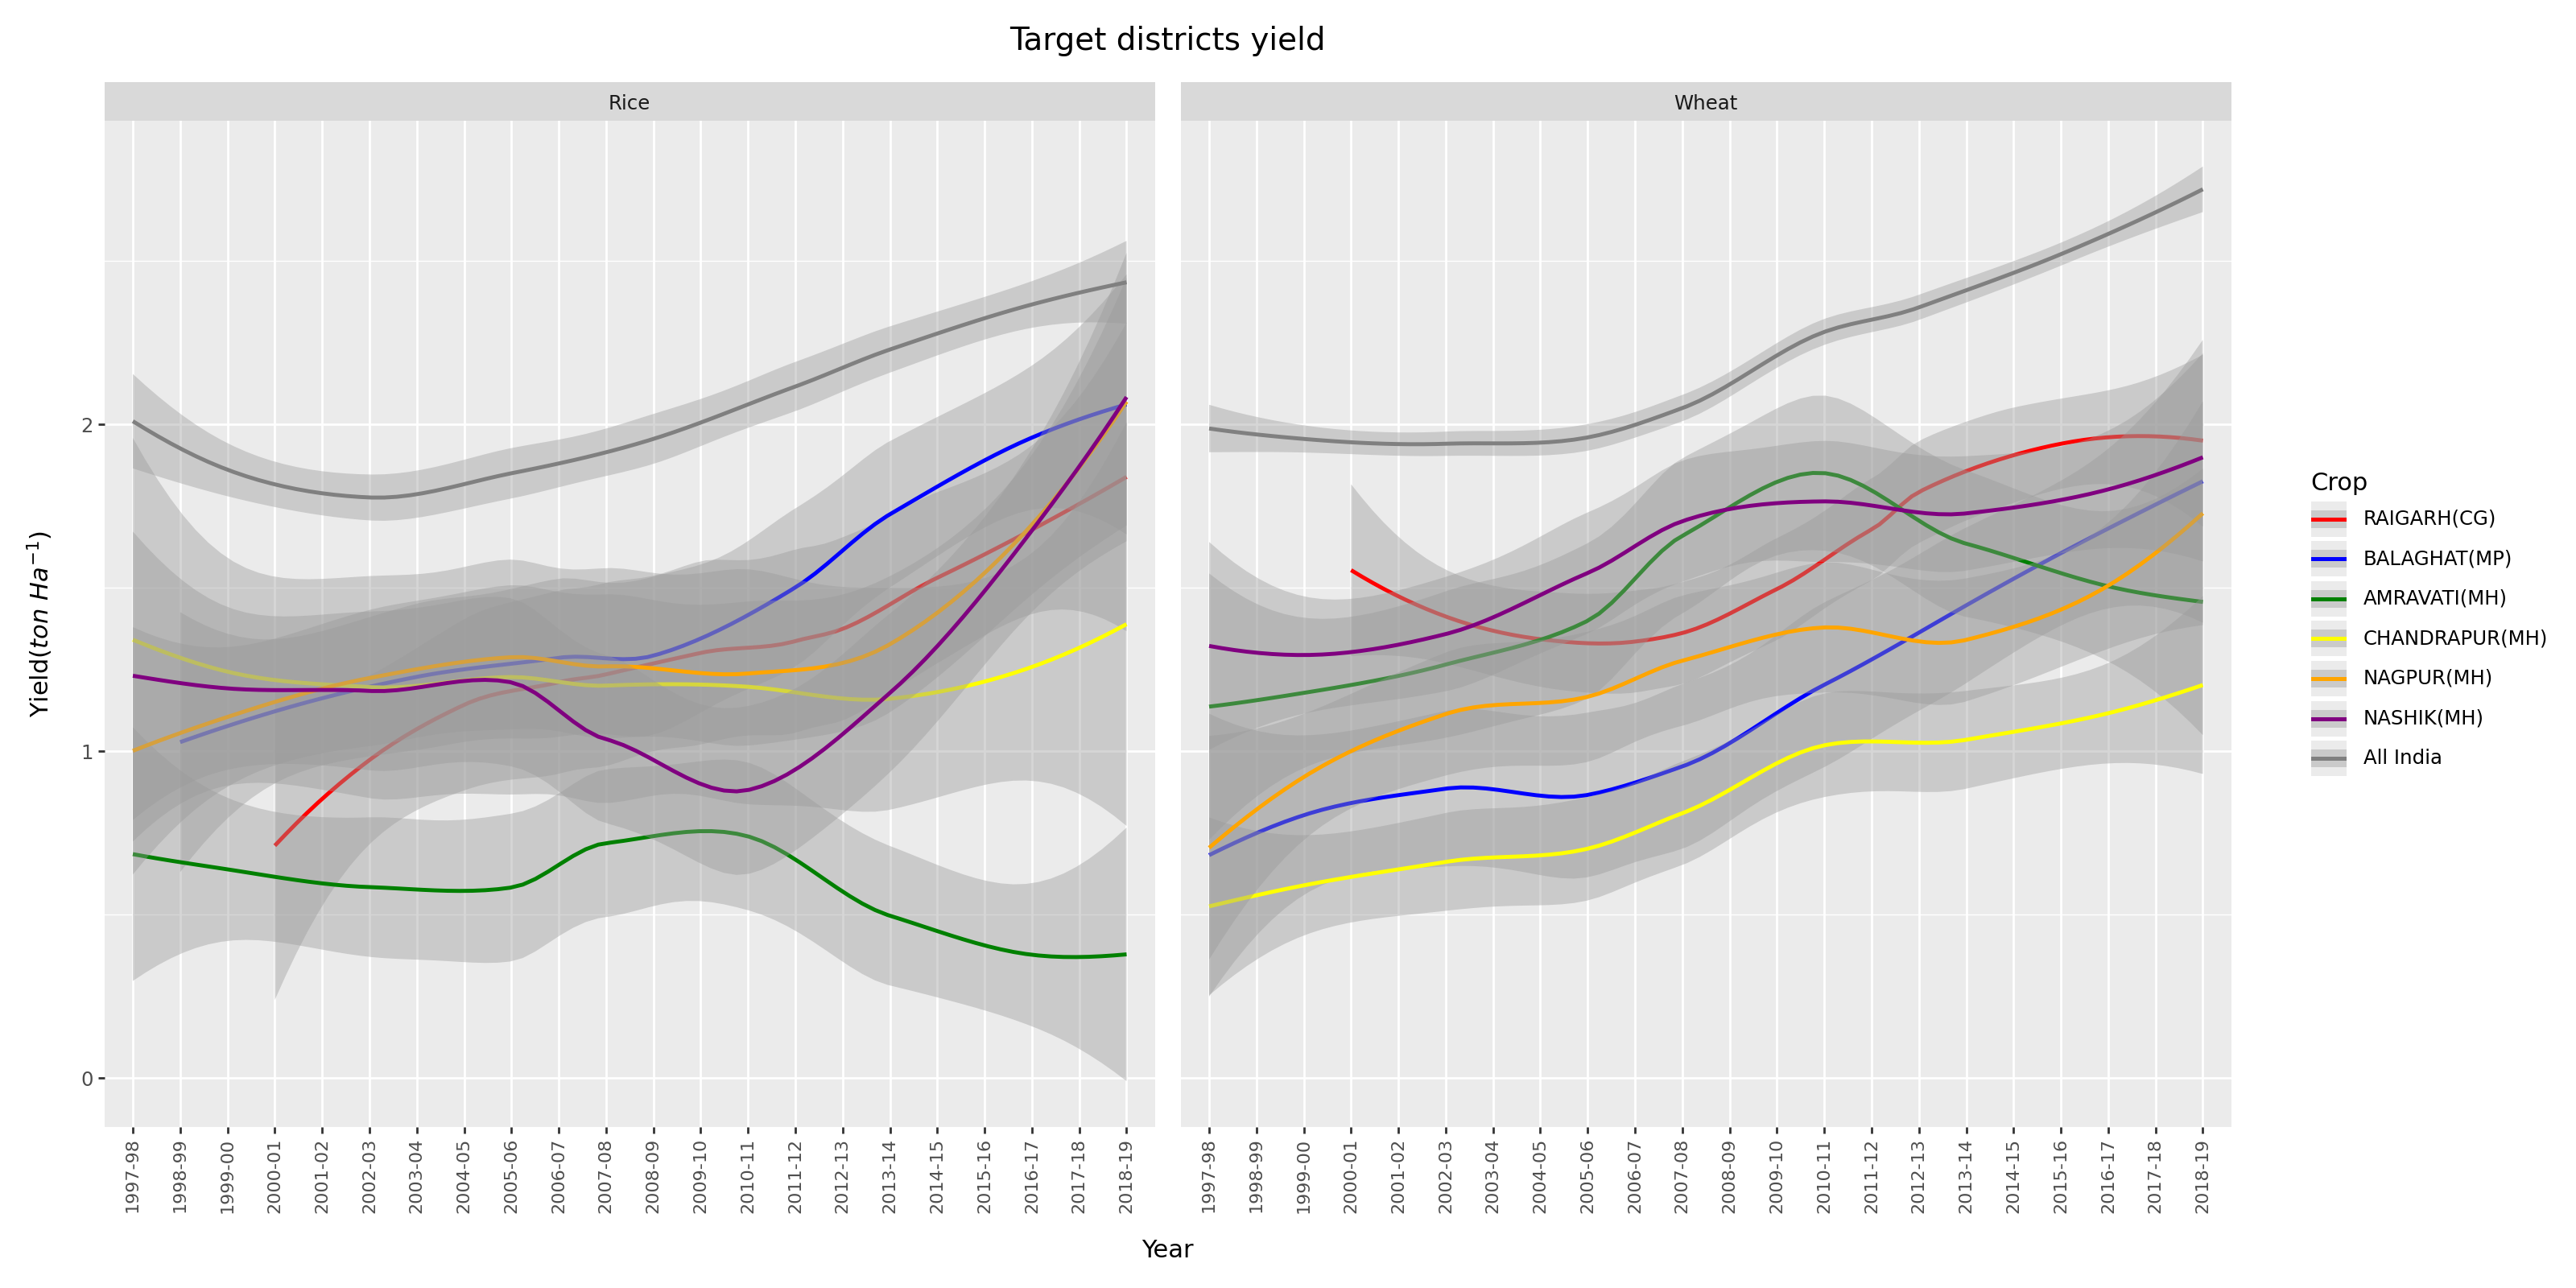

In [9]:
g = (ggplot(apy_df)
    + geom_smooth(aes(x='year', y='yield', color='district', group='district'), method='loess')
    + labs(title='Target districts yield', x='Year', y='Yield($ton\ Ha^{-1}$)')
    + scale_color_manual(name='Crop', values={'RAIGARH(CG)': 'red', 'BALAGHAT(MP)': 'blue', 'AMRAVATI(MH)': 'green', 'CHANDRAPUR(MH)': 'yellow', 'NAGPUR(MH)': 'orange', 'NASHIK(MH)': 'purple', 'All India': 'gray',})                                  
    + theme(
        figure_size=(16, 8),
        axis_text_x=element_text(angle=90, va="top", ha="center", size=8),
        plot_title=element_text(ha='center', size=14)
    )
    + facet_grid('.~apy_crop')
)
g.save(filename="target_district_yield.png", path=chart_dir, units='cm', dpi=300)
g


Create a graph of the cropping area over time to show the scale of possible projects that could be achieved within this district.

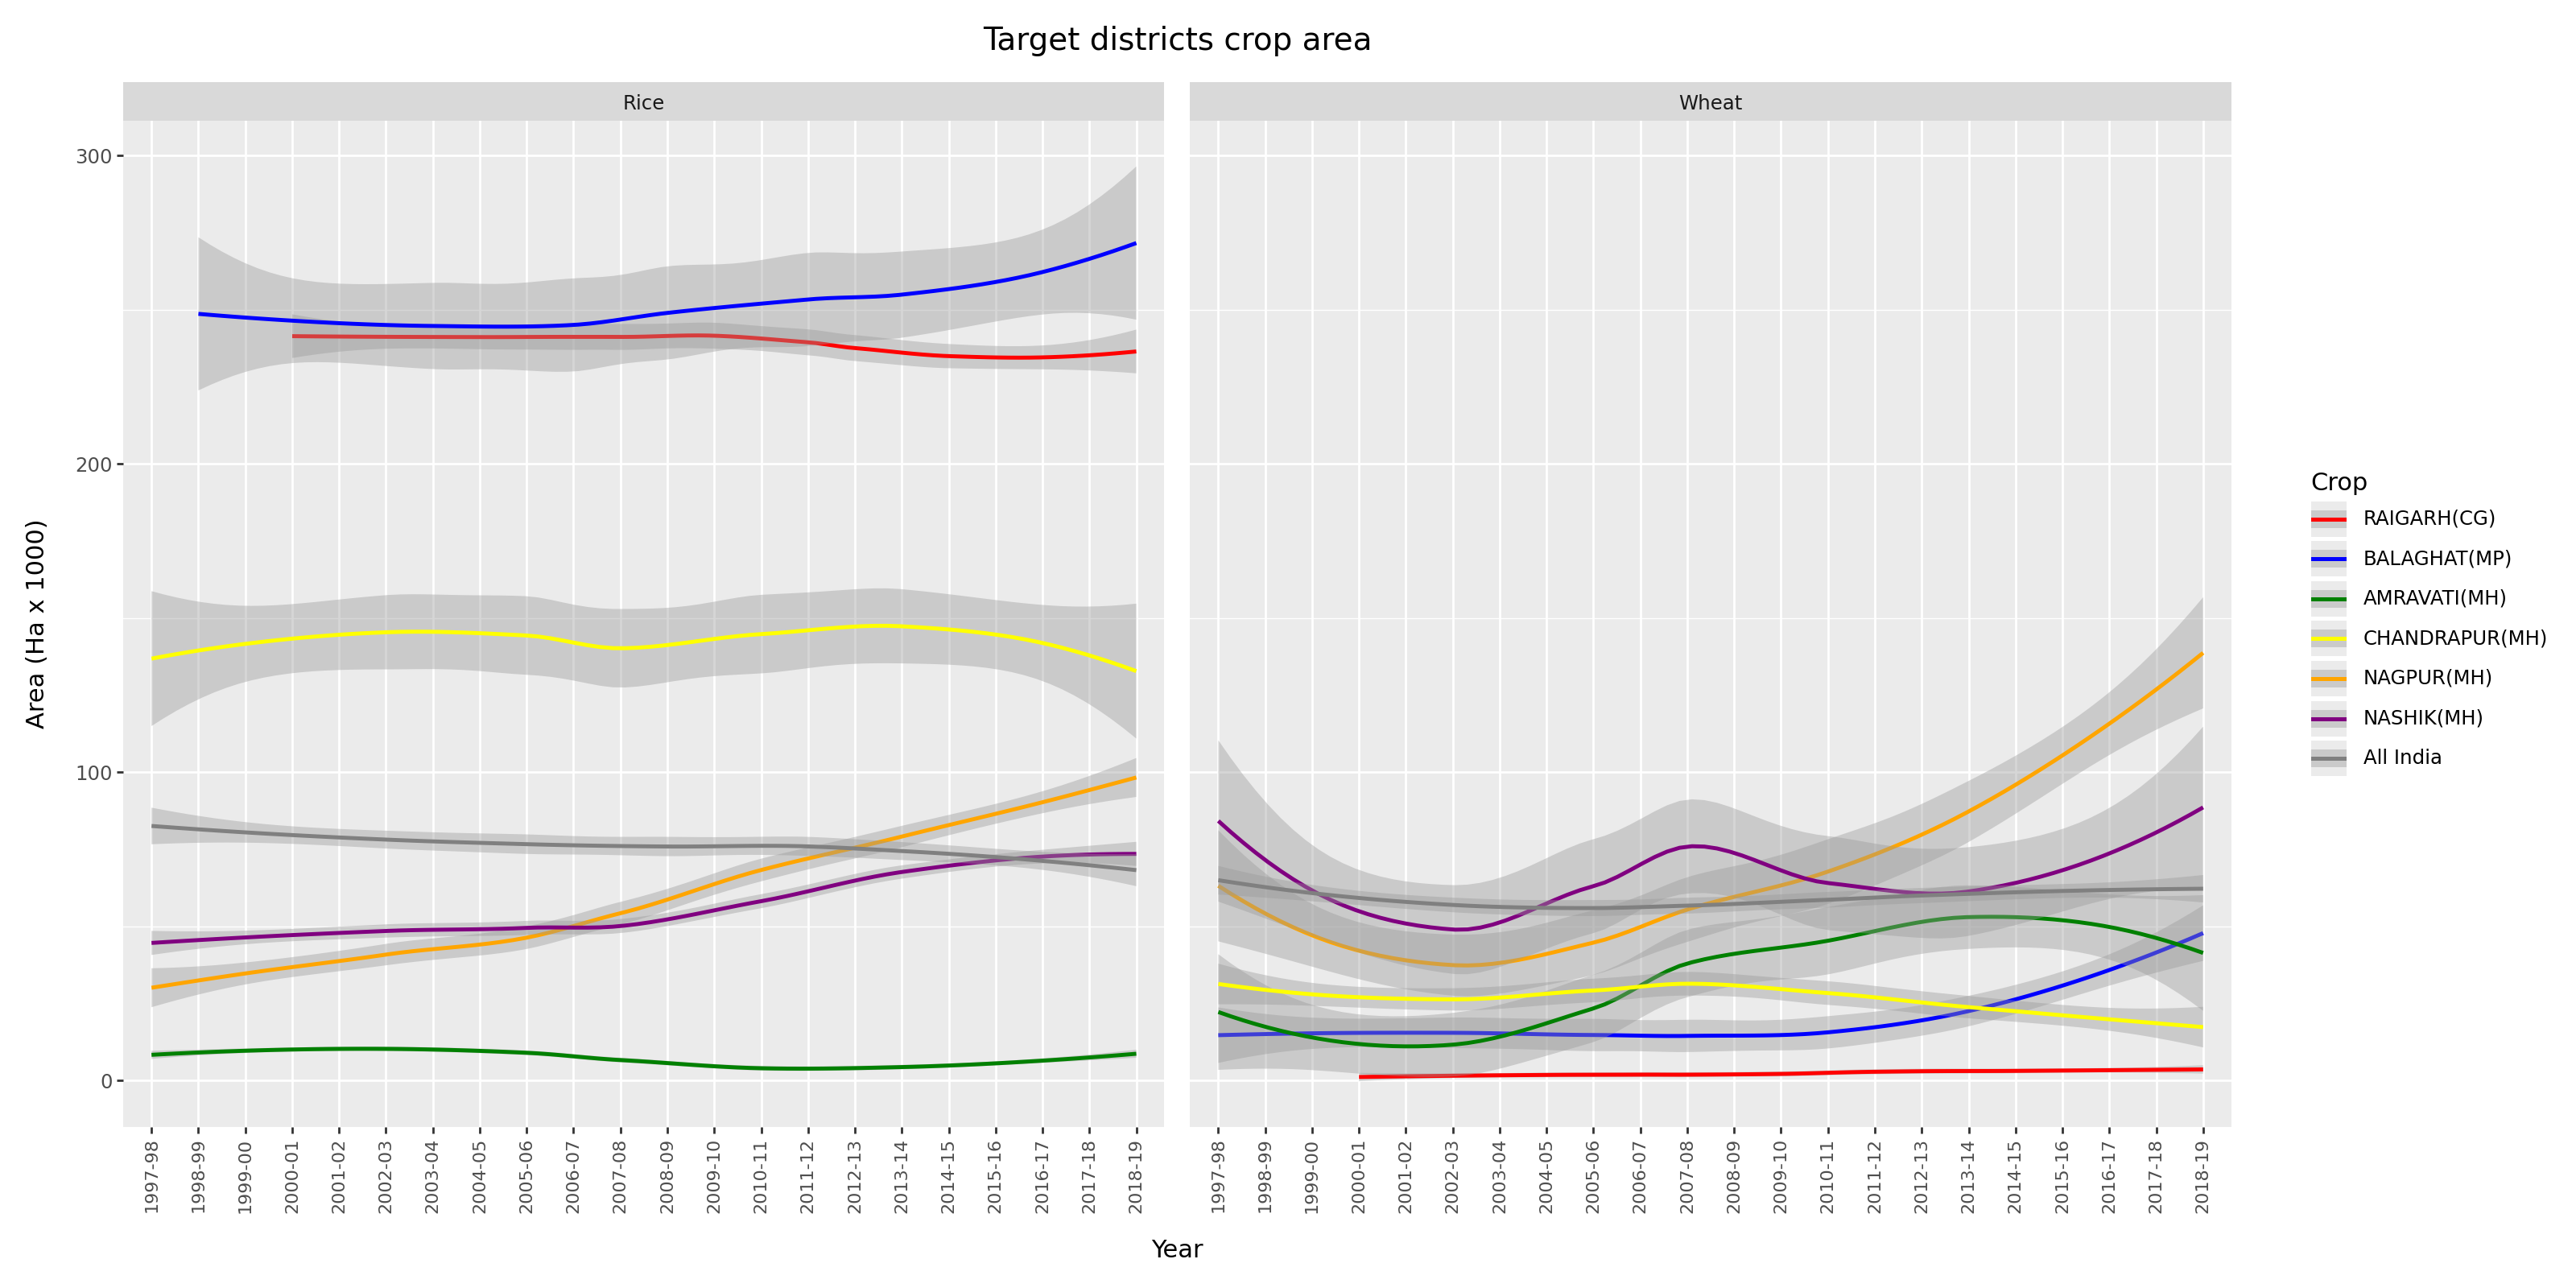

In [10]:
g = (ggplot(apy_df)
    + geom_smooth(aes(x='year', y='area/1000', color='district', group='district'), method='loess')
    + labs(title='Target districts crop area', x='Year', y='Area (Ha x 1000)')
    + scale_color_manual(name='Crop', values={'RAIGARH(CG)': 'red', 'BALAGHAT(MP)': 'blue', 'AMRAVATI(MH)': 'green', 'CHANDRAPUR(MH)': 'yellow', 'NAGPUR(MH)': 'orange', 'NASHIK(MH)': 'purple', 'All India': 'gray',})                                  
    + theme(
        figure_size=(16, 8),
        axis_text_x=element_text(angle=90, va="top", ha="center", size=8),
        plot_title=element_text(ha='center', size=14)
    )
    + facet_grid('.~apy_crop')
)
g.save(filename="target_district_area.png", path=chart_dir, units='cm', dpi=300)
g

